In [1]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent
ROOT

PosixPath('/Users/mohamedmafaz/Desktop/CFD_DiT')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
from scipy.interpolate import griddata
import matplotlib.ticker as tkr

from DDPM import LinearNoiseScheduler
from DiT_model import DiT
from VAE import VAE

In [3]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = f"{ROOT}/pretrained/sd-vae-ft-mse").to(device)

num_timesteps = 1000
beta_start    = 0.0001
beta_end      = 0.02


scheduler = LinearNoiseScheduler(num_timesteps  = num_timesteps,
                                     beta_start = beta_start,
                                     beta_end   = beta_end)


In [5]:
dit = DiT(d_model          = config["DiT"]["d_model"],
          g_channels       = config["DiT"]["g_channels"],
          grid_size        = config["DiT"]["grid_size"],
          patch_size       = config["DiT"]["patch_size"],
          timestep_emb_dim = config["DiT"]["timestep_emb_dim"],
          number_emb_dim   = config["DiT"]["number_emb_dim"],
          num_layers       = config["DiT"]["num_layers"],
          num_heads        = config["DiT"]["num_heads"])

vae.eval()
dit.eval()

vae.load_state_dict(torch.load(f"{ROOT}/models/VAE.pth", map_location = device))
dit.load_state_dict(torch.load(f'{ROOT}/models/DiT.pth', map_location = device))

<All keys matched successfully>

In [6]:
@torch.no_grad()
def sample(latent_grid_size: int, dit, vae, device, scheduler, number, **kwargs):
    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    for i in tqdm(reversed(range(1000))):
        noise_pred = dit(xt, 
                         torch.as_tensor(i).unsqueeze(0).to(device), 
                         torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.sample_prev_timestep(xt, noise_pred, torch.as_tensor(i).to(device))

    img_tensor = vae.decode(x0_pred)
    return img_tensor

In [58]:
@torch.no_grad()
def sample_ddim(latent_grid_size, dit, vae, device, scheduler, number, num_steps=100, seed=None):
    if seed is not None:
        torch.manual_seed(seed)

    xt = torch.randn((1, 4, latent_grid_size, latent_grid_size)).to(device)

    # e.g. [999, 979, 959, ..., 19, -1]  (evenly spaced, descending)
    step_indices = torch.linspace(0, 999, num_steps).long().flip(0)
    step_indices = torch.cat([step_indices, torch.tensor([-1])])  # -1 = terminal, x0

    for idx in tqdm(range(len(step_indices) - 1)):
        t = step_indices[idx].item()
        t_prev = step_indices[idx + 1].item()

        noise_pred = dit(xt,
                          torch.as_tensor(t).unsqueeze(0).to(device),
                          torch.as_tensor(number).unsqueeze(0).to(device))

        xt, x0_pred = scheduler.ddim_step(xt, noise_pred, t, t_prev, eta=0.0)

    img_tensor = vae.decode(x0_pred)
    return img_tensor

In [24]:
def predict(re_value, sample_fn, 
            re_mean, re_std, 
            u_mean, u_std, 
            v_mean, v_std, 
            P_mean, P_std, 
            grid_size,
            device="cpu", plot: bool = True, **kwargs):
    '''
    magic
    '''
    img = sample_fn(32, dit, vae, device, scheduler, (re_value - re_mean) / re_std)

    img_np = img.detach().cpu().numpy() if hasattr(img, "detach") else np.array(img)

    img_np = img_np[0]

    u = (img_np[0] * u_std) + u_mean
    v = (img_np[1] * v_std) + v_mean
    p = (img_np[2] * P_std) + P_mean

    mag = np.sqrt(u**2 + v**2)

    dx = 1.0 / (grid_size - 1)  # grid spacing over [0, 1]

    du_dx = np.gradient(u, dx, axis=1)
    du_dy = np.gradient(u, dx, axis=0)
    dv_dy = np.gradient(v, dx, axis=0)
    dv_dx = np.gradient(v, dx, axis=1)

    d2u_dx2 = np.gradient(du_dx, dx, axis=1)
    d2u_dy2 = np.gradient(du_dy, dx, axis=0)
    d2v_dy2 = np.gradient(dv_dy, dx, axis=0)
    d2v_dx2 = np.gradient(dv_dx, dx, axis=1)

    dP_dx = np.gradient(p, dx, axis=1)
    dP_dy = np.gradient(p, dx, axis=0)

    momentum_res_x = ((u * du_dx) + (v * du_dy)) + dP_dx - (1/re_value) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = ((u * dv_dx) + (v * dv_dy)) + dP_dy - (1/re_value) * (d2v_dx2 + d2v_dy2)

    momentum_res = (momentum_res_x ** 2 + momentum_res_y ** 2) ** 0.5

    divergence = du_dx + dv_dy

    if plot:
        x_grid = np.linspace(0, 1, grid_size)
        y_grid = np.linspace(0, 1, grid_size)

        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        c0 = axes[0].contourf(x_grid, y_grid, u, levels=200, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        c1 = axes[1].contourf(x_grid, y_grid, v, levels=200, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        c2 = axes[2].contourf(x_grid, y_grid, p, levels=200, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        axes[2].set_title("P (Pa)")

        c3 = axes[3].contourf(x_grid, y_grid, mag, levels=200, cmap="jet")
        fig.colorbar(c3, ax=axes[3])
        axes[3].set_title("|U|")

        c4 = axes[4].contourf(x_grid, y_grid, divergence, levels=200, cmap="seismic")
        fig.colorbar(c4, ax=axes[4], label="∇·u")
        axes[4].set_title(f"divergence mean: {divergence.mean():.2f}")

        div_m = axes[5].contourf(x_grid, y_grid, momentum_res, levels=200, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momentum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, p, divergence, momentum_res, mag

In [20]:
meta = config["Data"]['meta']
RE_MEAN = config["Stats"][meta]["Re_Mean"]
RE_STD = config["Stats"][meta]["Re_Std"]

U_MEAN = config["Stats"][meta]["U_MEAN"]
U_STD = config["Stats"][meta]["U_STD"]

V_MEAN = config["Stats"][meta]["V_MEAN"]
V_STD = config["Stats"][meta]["V_STD"]

P_MEAN = config["Stats"][meta]["P_MEAN"]
P_STD = config["Stats"][meta]["P_STD"]

100%|██████████| 1/1 [00:03<00:00,  3.60s/it]


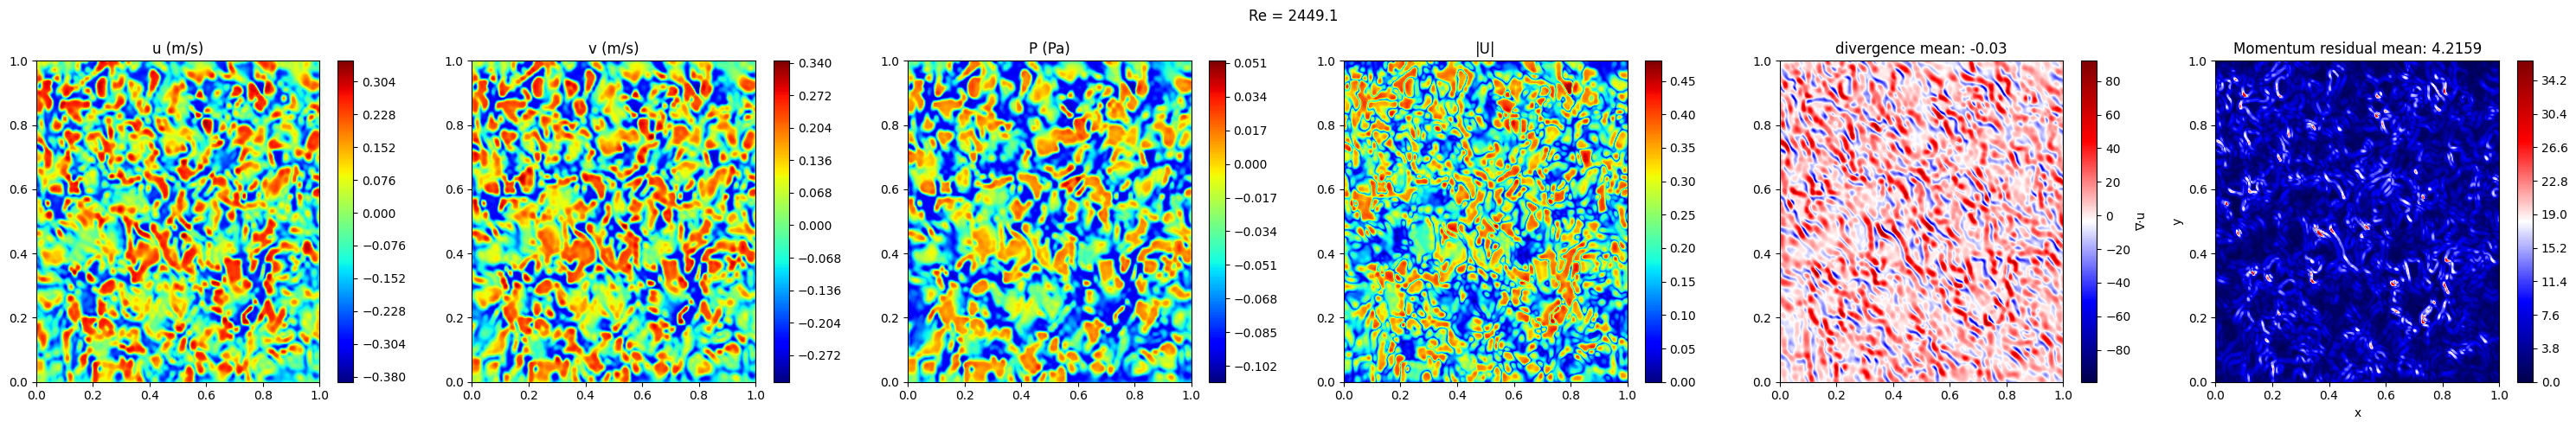

In [57]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 2449.1, sample_fn = sample_ddim, 
                                   re_mean = RE_MEAN, re_std = RE_STD, 
                                   u_mean = U_MEAN,   u_std = U_STD, 
                                   v_mean = V_MEAN,   v_std = V_STD, 
                                   P_mean = P_MEAN,   P_std = P_STD,
                                   grid_size = 256,
                                   device = "cpu", plot = True
                                   )

1000it [00:55, 17.88it/s]


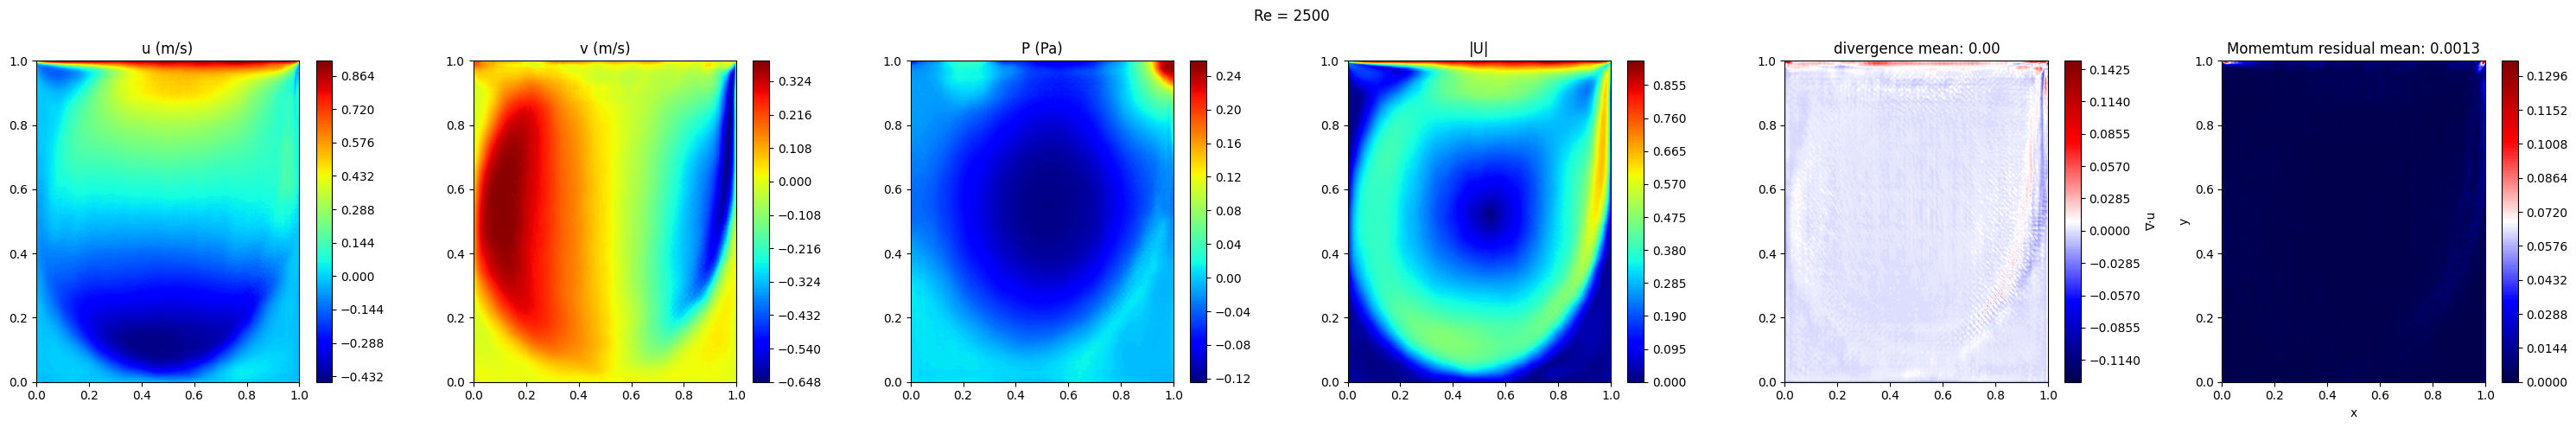

In [12]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 2500, sample_fn = sample, 
                                                 re_mean = RE_MEAN, re_std = RE_STD, 
                                                 u_mean = U_MEAN,   u_std = U_STD, 
                                                 v_mean = V_MEAN,   v_std = V_STD, 
                                                 P_mean = P_MEAN,   P_std = P_STD,
                                                 grid_size = 256,
                                                 device = "cpu", plot = True
                                                 )  

1000it [00:50, 19.74it/s]


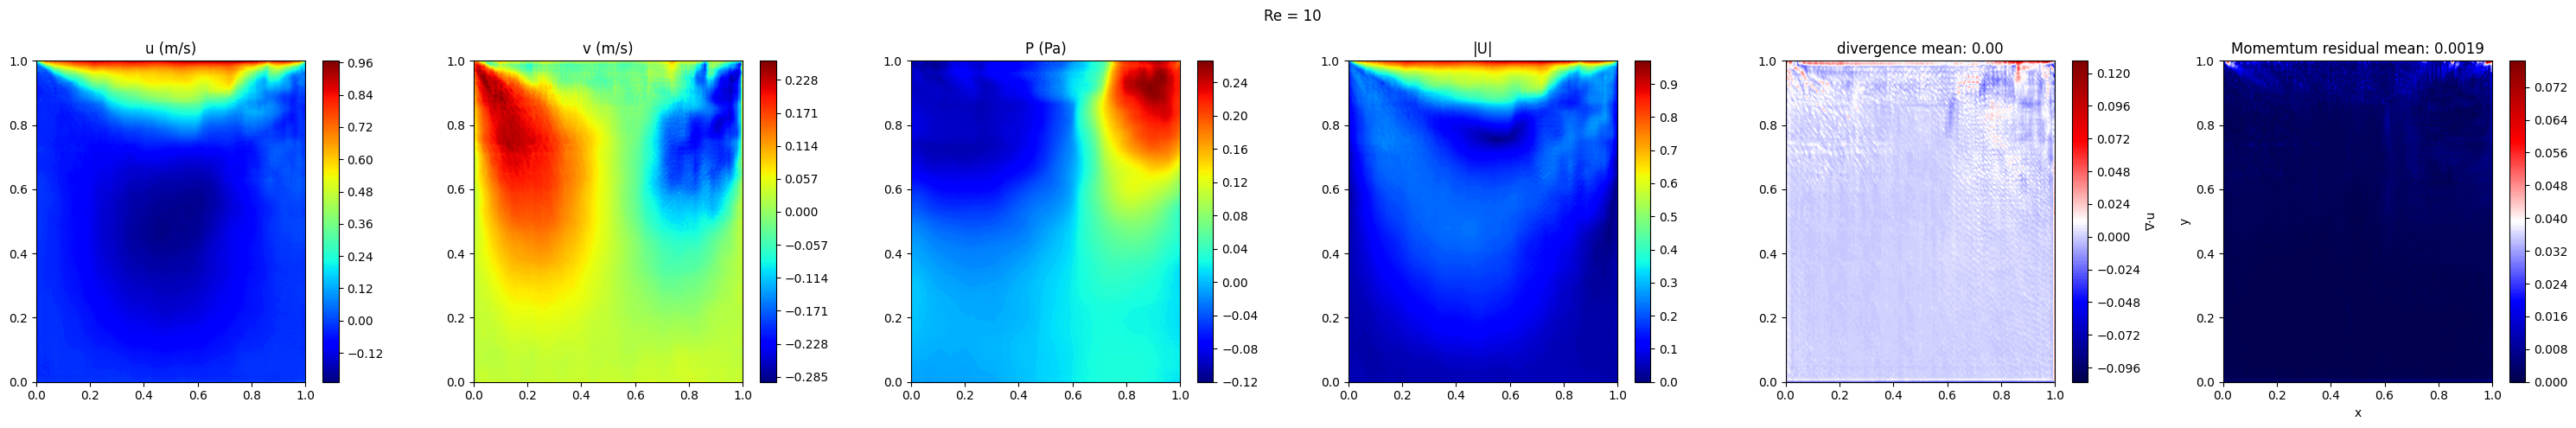

In [13]:
u, v, P, divergence, momentum_res, mag = predict(re_value = 10, sample_fn = sample, 
                                                 re_mean = RE_MEAN, re_std = RE_STD, 
                                                 u_mean = U_MEAN,   u_std = U_STD, 
                                                 v_mean = V_MEAN,   v_std = V_STD, 
                                                 P_mean = P_MEAN,   P_std = P_STD,
                                                 grid_size = 256,
                                                 device = "cpu", plot = True
                                                 )  

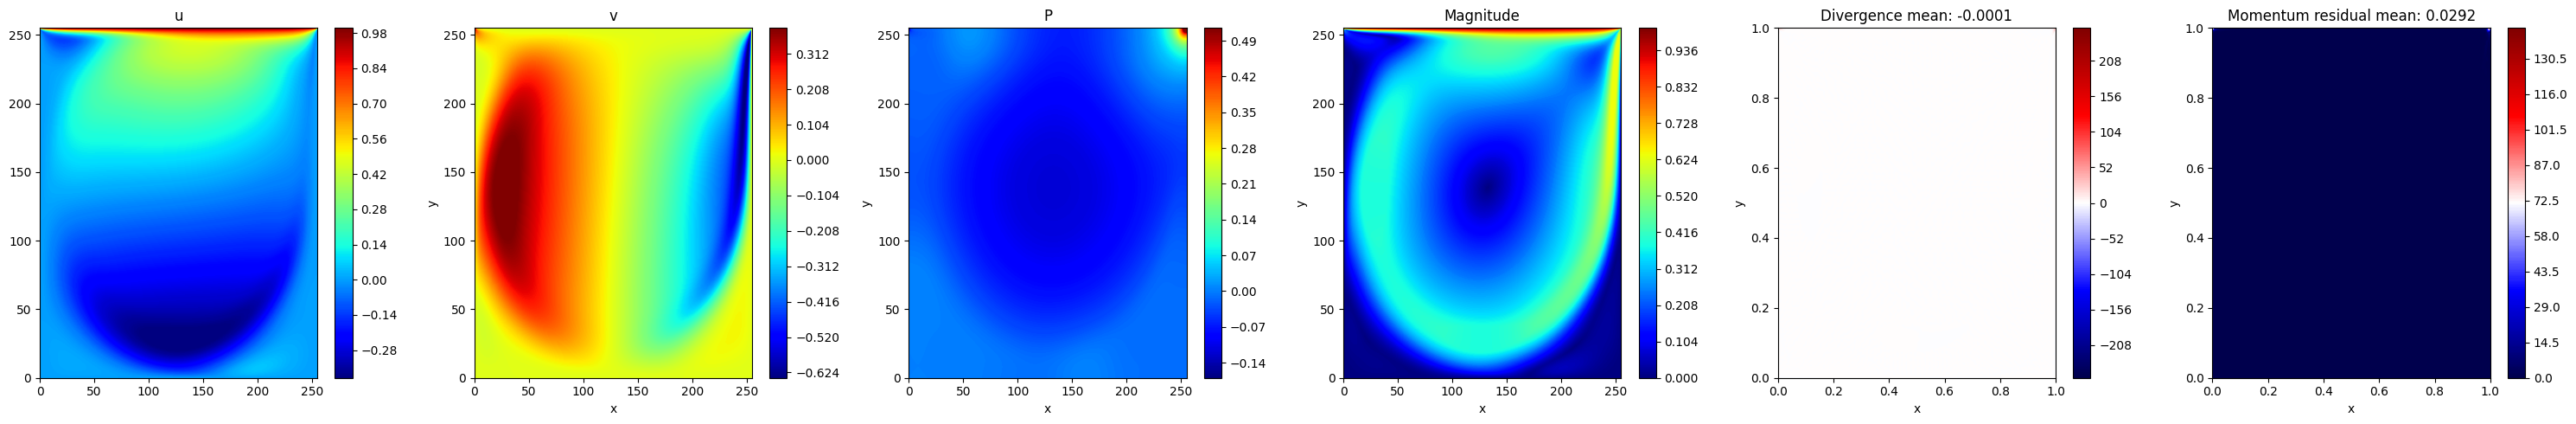

In [54]:
def ground_truth(re: float, plot: bool):
    assert f"Re_{re}.csv" in os.listdir("../Data/Problems/Lid_Driven_domain"), f"{re} make sure re is in the csv folder"
    df = pd.read_csv(f"../Data/Problems/Lid_Driven_domain/Re_{re}.csv", index_col = 0)

    lin = np.linspace(0, 1, 256)

    df = df.dropna(subset=["x", "y", "u (m/s)", "v (m/s)", "p (Pa)"])

    x = df['x']
    y = df['y']
    u = df["u (m/s)"].values.astype(np.float32)
    v = df["v (m/s)"].values.astype(np.float32)
    P = df["p (Pa)"].values.astype(np.float32)

    points = np.stack([x, y], axis=1)

    grid_x, grid_y = np.meshgrid(lin, lin)

    u_grid = griddata(points, u, (grid_x, grid_y), method="linear", fill_value=0.0)
    v_grid = griddata(points, v, (grid_x, grid_y), method="linear", fill_value=0.0)
    P_grid = griddata(points, P, (grid_x, grid_y), method="linear", fill_value=0.0)

    dx = lin[1] - lin[0]
    dy = lin[1] - lin[0]

    du_dx = np.gradient(u_grid, dx, axis = 1)
    du_dy = np.gradient(u_grid, dy, axis = 0)
    dv_dy = np.gradient(v_grid, dy, axis = 0)
    dv_dx = np.gradient(v_grid, dx, axis = 1)

    d2u_dx2 = np.gradient(du_dx, dx, axis = 1)
    d2u_dy2 = np.gradient(du_dy, dy, axis = 0)
    d2v_dy2 = np.gradient(dv_dy, dy, axis = 0)
    d2v_dx2 = np.gradient(dv_dx, dx, axis = 1)

    dP_dx = np.gradient(P_grid, dx, axis = 1)
    dP_dy = np.gradient(P_grid, dy, axis = 0)

    div = du_dx + dv_dy

    momentum_res_x = (1 * ((u_grid * du_dx) + (v_grid * du_dy))) + dP_dx - (1/re) * (d2u_dx2 + d2u_dy2)
    momentum_res_y = (1 * ((u_grid * dv_dx) + (v_grid * dv_dy))) + dP_dy - (1/re) * (d2v_dx2 + d2v_dy2)

    momentum_res = (momentum_res_x ** 2 + momentum_res_y ** 2) ** 0.5

    mag = np.sqrt(u_grid**2 + v_grid**2)

    if plot:
        fig, axes = plt.subplots(1, 6, figsize=(30, 5))

        u_c = axes[0].contourf(u_grid, levels=300, cmap="jet")
        plt.colorbar(u_c, ax=axes[0])
        axes[0].set_title("u")

        v_c = axes[1].contourf(v_grid, levels=300, cmap="jet")
        plt.colorbar(v_c, ax=axes[1])
        axes[1].set_title("v")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")

        p_c = axes[2].contourf(P_grid, levels=300, cmap="jet")
        plt.colorbar(p_c, ax=axes[2])
        axes[2].set_title("P")
        axes[2].set_xlabel("x")
        axes[2].set_ylabel("y")

        mag_c = axes[3].contourf(mag, levels=300, cmap="jet")
        plt.colorbar(mag_c, ax=axes[3])
        axes[3].set_title("Magnitude")
        axes[3].set_xlabel("x")
        axes[3].set_ylabel("y")

        div_c = axes[4].contourf(grid_x, grid_y, div, levels=300, cmap="seismic")
        plt.colorbar(div_c, ax=axes[4])
        axes[4].set_title(f"Divergence mean: {div.mean():.4f}")
        axes[4].set_xlabel("x")
        axes[4].set_ylabel("y")

        div_m = axes[5].contourf(grid_x, grid_y, momentum_res, levels=300, cmap="seismic")
        plt.colorbar(div_m, ax=axes[5])
        axes[5].set_title(f"Momentum residual mean: {momentum_res.mean():.4f}")
        axes[5].set_xlabel("x")
        axes[5].set_ylabel("y")

        plt.tight_layout()
        plt.show()

    return u_grid, v_grid, P_grid, div, momentum_res, mag


u_grid, v_grid, P_grid, div, momentum_res, mag = ground_truth(re = 2499.1, plot=True)

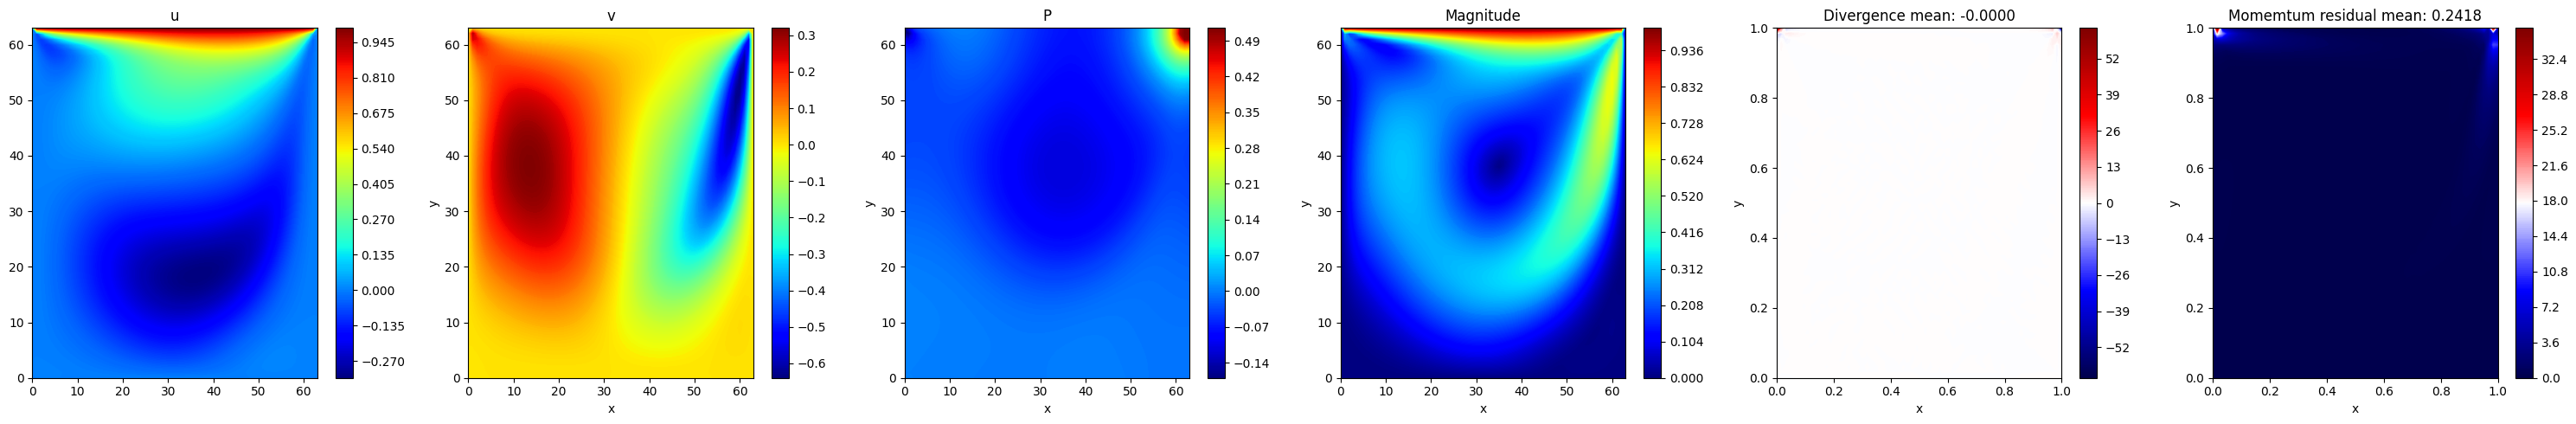

100%|██████████| 100/100 [00:05<00:00, 18.52it/s]


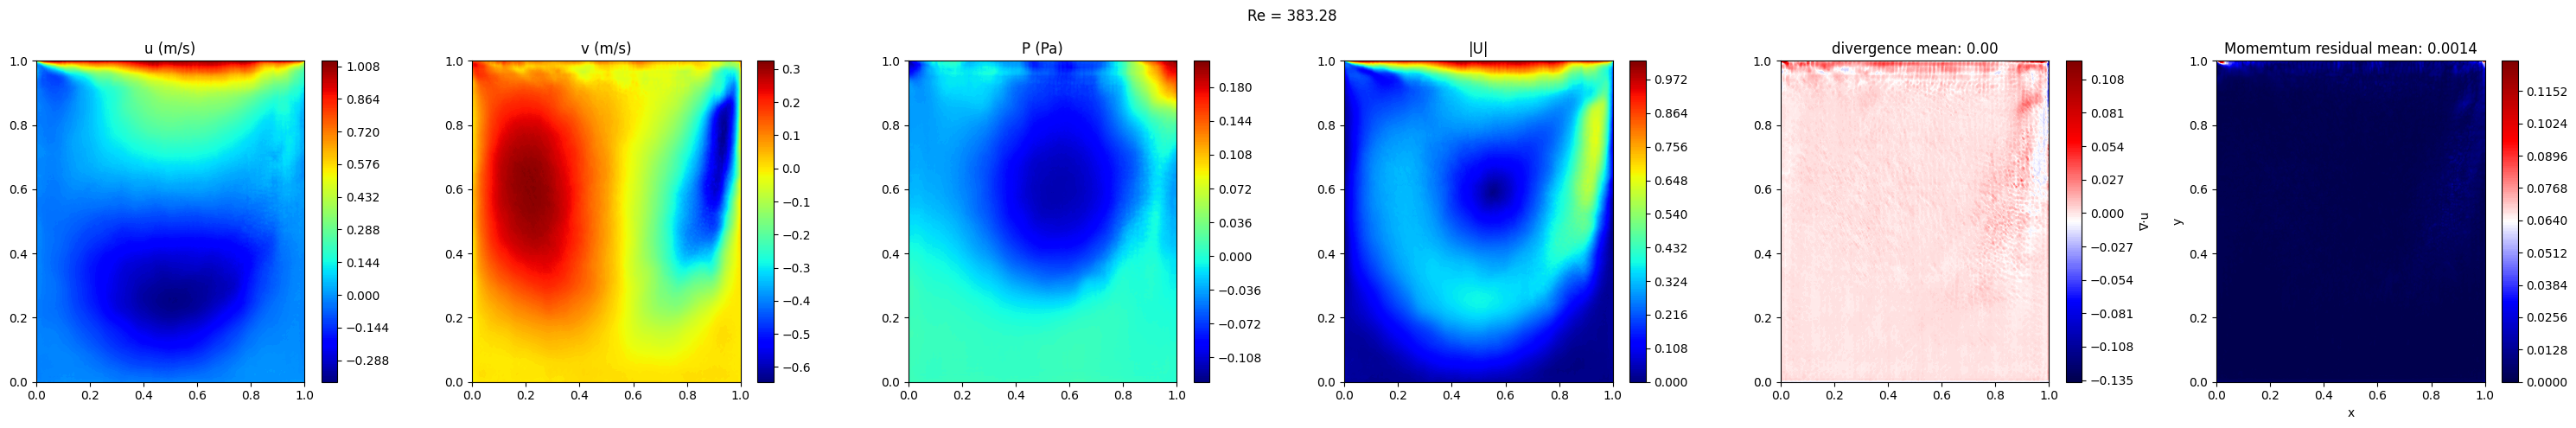

In [18]:
re = 383.28

u_grid_actual, v_grid_actual, P_grid, div_actual, momentum_res_actual, mag_actual = ground_truth(re = re, plot=True)

u, v, P, divergence, momentum_res, mag = predict(re_value = re, sample_fn = sample_ddim, 
                                                 re_mean = RE_MEAN, re_std = RE_STD, 
                                                 u_mean = U_MEAN,   u_std = U_STD, 
                                                 v_mean = V_MEAN,   v_std = V_STD, 
                                                 P_mean = P_MEAN,   P_std = P_STD,
                                                 grid_size = 256,
                                                 device = "cpu", plot = True
                                                 )  

100%|██████████| 100/100 [00:04<00:00, 22.24it/s]


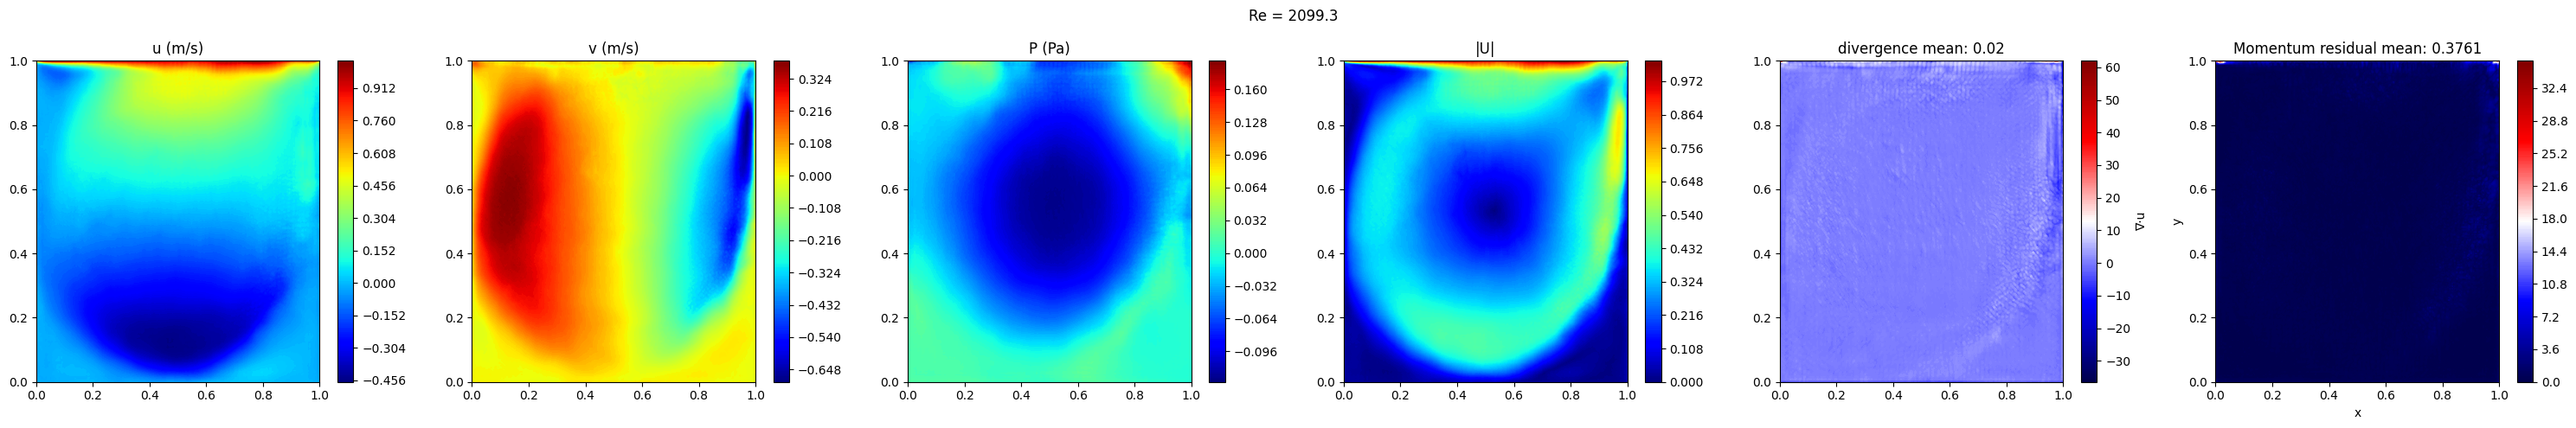

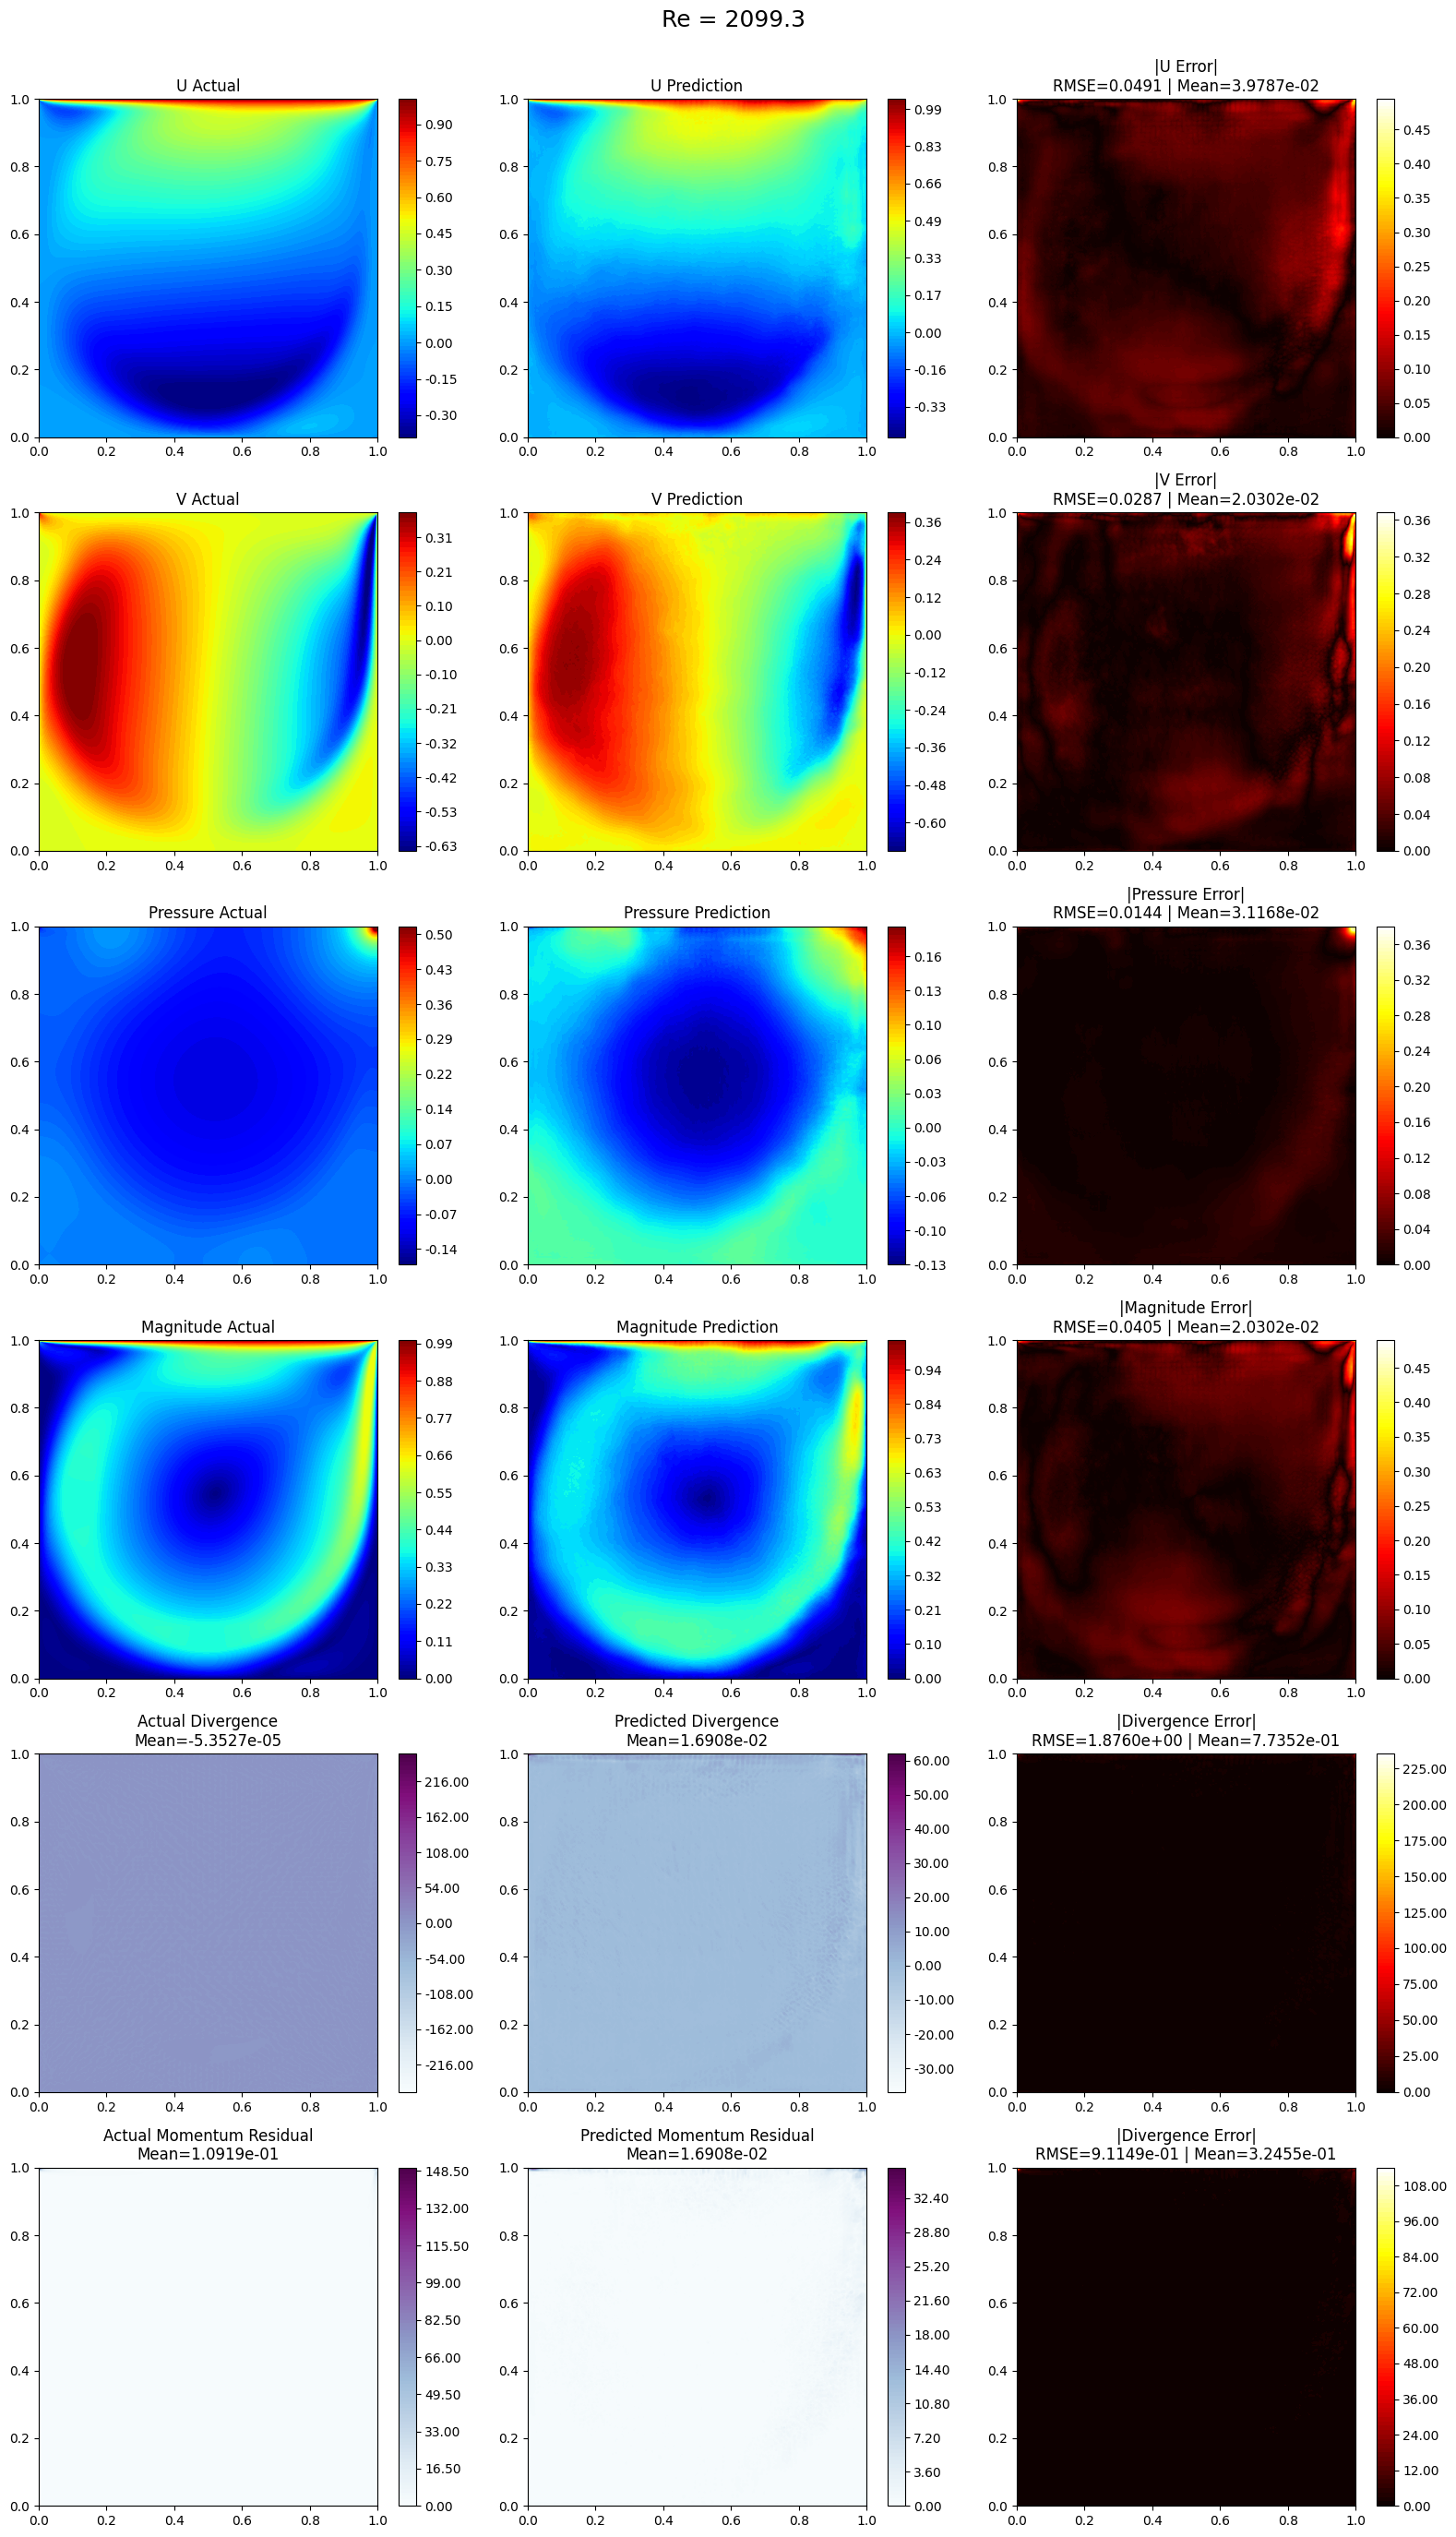

  0%|          | 0/320 [00:14<?, ?it/s]


In [53]:
import imageio.v2 as imageio

re_s = [float(i.split("_")[1].split(".csv")[0]) for i in os.listdir(f"{ROOT}/Data/Problems/Lid_Driven_domain")]

errors = {}
frames = []

with imageio.get_writer("../renders/backward_facing_step.mp4", fps=15) as writer:
    for re in tqdm(re_s):

        err = {}

        u_grid_actual, v_grid_actual, p_grid_actual, div_actual, momentum_res_actual, mag_actual = ground_truth(
            re=re,
            plot=False
        )

        u_grid_pred, v_grid_pred, p_grid_pred, div_pred, momentum_res_pred, mag_pred = predict(re_value = re, sample_fn = sample_ddim, 
                                                                                               re_mean = RE_MEAN, re_std = RE_STD, 
                                                                                               u_mean = U_MEAN,   u_std = U_STD, 
                                                                                               v_mean = V_MEAN,   v_std = V_STD, 
                                                                                               P_mean = P_MEAN,   P_std = P_STD,
                                                                                               grid_size = 256,
                                                                                               device = "cpu", plot = True
                                                                                               )     
        u_grid_pred       = np.array(u_grid_pred)
        v_grid_pred       = np.array(v_grid_pred)
        p_grid_pred       = np.array(p_grid_pred)
        mag_pred          = np.array(mag_pred)
        div_pred          = np.array(div_pred)
        momentum_res_pred = np.array(momentum_res_pred)

        mask = np.ones((256, 256))
        bool_mask = mask.astype(bool)

        # U
        u_difference = np.abs(u_grid_actual - u_grid_pred)
        u_rmse = np.sqrt(((u_grid_actual[bool_mask] - u_grid_pred[bool_mask]) ** 2).mean())

        # V
        v_difference = np.abs(v_grid_actual - v_grid_pred)
        v_rmse = np.sqrt(((v_grid_actual[bool_mask] - v_grid_pred[bool_mask]) ** 2).mean())

        # Pressure
        p_difference = np.abs(p_grid_actual - p_grid_pred)
        p_rmse = np.sqrt(((p_grid_actual[bool_mask] - p_grid_pred[bool_mask]) ** 2).mean())

        # Velocity magnitude
        mag_difference = np.abs(mag_actual - mag_pred)
        mag_rmse = np.sqrt(((mag_actual[bool_mask] - mag_pred[bool_mask]) ** 2).mean())

        # Divergence
        div_difference = np.abs(div_actual - div_pred)
        div_rmse = np.sqrt(((div_actual[bool_mask] - div_pred[bool_mask]) ** 2).mean())

        # Momentum residual
        mom_difference = np.abs(momentum_res_actual - momentum_res_pred)
        mom_rmse = np.sqrt(((momentum_res_actual[bool_mask] - momentum_res_pred[bool_mask]) ** 2).mean())

        err["u_error"]   = u_rmse.item()
        err["v_error"]   = v_rmse.item()
        err["p_error"]   = p_rmse.item()
        err["mag_error"] = mag_rmse.item()
        err["div_error"] = div_rmse.item()
        err["div_error"] = mom_rmse.item()
        # err["isTrain"]   = True if post_train_re[re_idx] in train_test_re['train_re'] else False

        errors[re] = err

        fig, axes = plt.subplots(6, 3, figsize=(16, 28))

        lin = torch.linspace(0, 1, 256)

        ####################################################################
        # U
        ####################################################################
        c = axes[0, 0].contourf(lin, lin,  np.where(bool_mask, u_grid_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[0, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[0, 0].set_title("U Actual")

        c = axes[0, 1].contourf(lin, lin, np.where(bool_mask, u_grid_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[0, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[0, 1].set_title("U Prediction")

        c = axes[0, 2].contourf(lin, lin, np.where(bool_mask, u_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[0, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[0, 2].set_title(f"|U Error|\nRMSE={u_rmse:.4f} | Mean={np.abs(u_grid_actual[bool_mask] - u_grid_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # V
        ####################################################################
        c = axes[1, 0].contourf(lin, lin, np.where(bool_mask, v_grid_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[1, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[1, 0].set_title("V Actual")

        c = axes[1, 1].contourf(lin, lin, np.where(bool_mask, v_grid_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[1, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[1, 1].set_title("V Prediction")

        c = axes[1, 2].contourf(lin, lin, np.where(bool_mask, v_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[1, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[1, 2].set_title(f"|V Error|\nRMSE={v_rmse:.4f} | Mean={np.abs(v_grid_actual[bool_mask] - v_grid_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # Pressure
        ####################################################################
        c = axes[2, 0].contourf(lin, lin, np.where(bool_mask, p_grid_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[2, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[2, 0].set_title("Pressure Actual")

        c = axes[2, 1].contourf(lin, lin, np.where(bool_mask, p_grid_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[2, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[2, 1].set_title("Pressure Prediction")

        c = axes[2, 2].contourf(lin, lin, np.where(bool_mask, p_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[2, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[2, 2].set_title(f"|Pressure Error|\nRMSE={p_rmse:.4f} | Mean={np.abs(mag_actual[bool_mask] - mag_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # Magnitude
        ####################################################################
        c = axes[3, 0].contourf(lin, lin, np.where(bool_mask, mag_actual, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[3, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[3, 0].set_title("Magnitude Actual")

        c = axes[3, 1].contourf(lin, lin, np.where(bool_mask, mag_pred, np.nan), levels=100, cmap="jet")
        plt.colorbar(c, ax=axes[3, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[3, 1].set_title("Magnitude Prediction")

        c = axes[3, 2].contourf(lin, lin, np.where(bool_mask, mag_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[3, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[3, 2].set_title(f"|Magnitude Error|\nRMSE={mag_rmse:.4f} | Mean={np.abs(v_grid_actual[bool_mask] - v_grid_pred[bool_mask]).mean():.4e}")

        ####################################################################
        # Divergence
        ####################################################################
        c = axes[4, 0].contourf(lin, lin, np.where(bool_mask, div_actual, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[4, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[4, 0].set_title(f"Actual Divergence\nMean={torch.tensor(div_actual[bool_mask]).mean():.4e}")

        c = axes[4, 1].contourf(lin, lin, np.where(bool_mask, div_pred, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[4, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[4, 1].set_title(f"Predicted Divergence\nMean={div_pred[bool_mask].mean():.4e}")

        c = axes[4, 2].contourf(lin, lin, np.where(bool_mask, div_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[4, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[4, 2].set_title(f"|Divergence Error|\nRMSE={div_rmse:.4e} | Mean={np.abs(div_actual[bool_mask] - div_pred[bool_mask]).mean():.4e}")
        
        
        ####################################################################
        # Momentum residual
        ####################################################################
        c = axes[5, 0].contourf(lin, lin, np.where(bool_mask, momentum_res_actual, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[5, 0], format=tkr.FormatStrFormatter('%.2f'))
        axes[5, 0].set_title(f"Actual Momentum Residual\nMean={torch.tensor(momentum_res_actual[bool_mask]).mean():.4e}")

        c = axes[5, 1].contourf(lin, lin, np.where(bool_mask, momentum_res_pred, np.nan), levels=100, cmap="BuPu")
        plt.colorbar(c, ax=axes[5, 1], format=tkr.FormatStrFormatter('%.2f'))
        axes[5, 1].set_title(f"Predicted Momentum Residual\nMean={div_pred.mean():.4e}")

        c = axes[5, 2].contourf(lin, lin, np.where(bool_mask, mom_difference, np.nan), levels=100, cmap="hot")
        plt.colorbar(c, ax=axes[5, 2], format=tkr.FormatStrFormatter('%.2f'))
        axes[5, 2].set_title(f"|Divergence Error|\nRMSE={mom_rmse:.4e} | Mean={np.abs(momentum_res_actual[bool_mask] - momentum_res_pred[bool_mask]).mean():.4e}")


        plt.suptitle(f"Re = {re}", fontsize=18)
        plt.tight_layout(rect=[0, 0, 1, 0.98])
        
        fig.canvas.draw()
        frame = np.asarray(fig.canvas.renderer.buffer_rgba())
        writer.append_data(frame)
        # plt.close(fig)

        plt.show()
        break


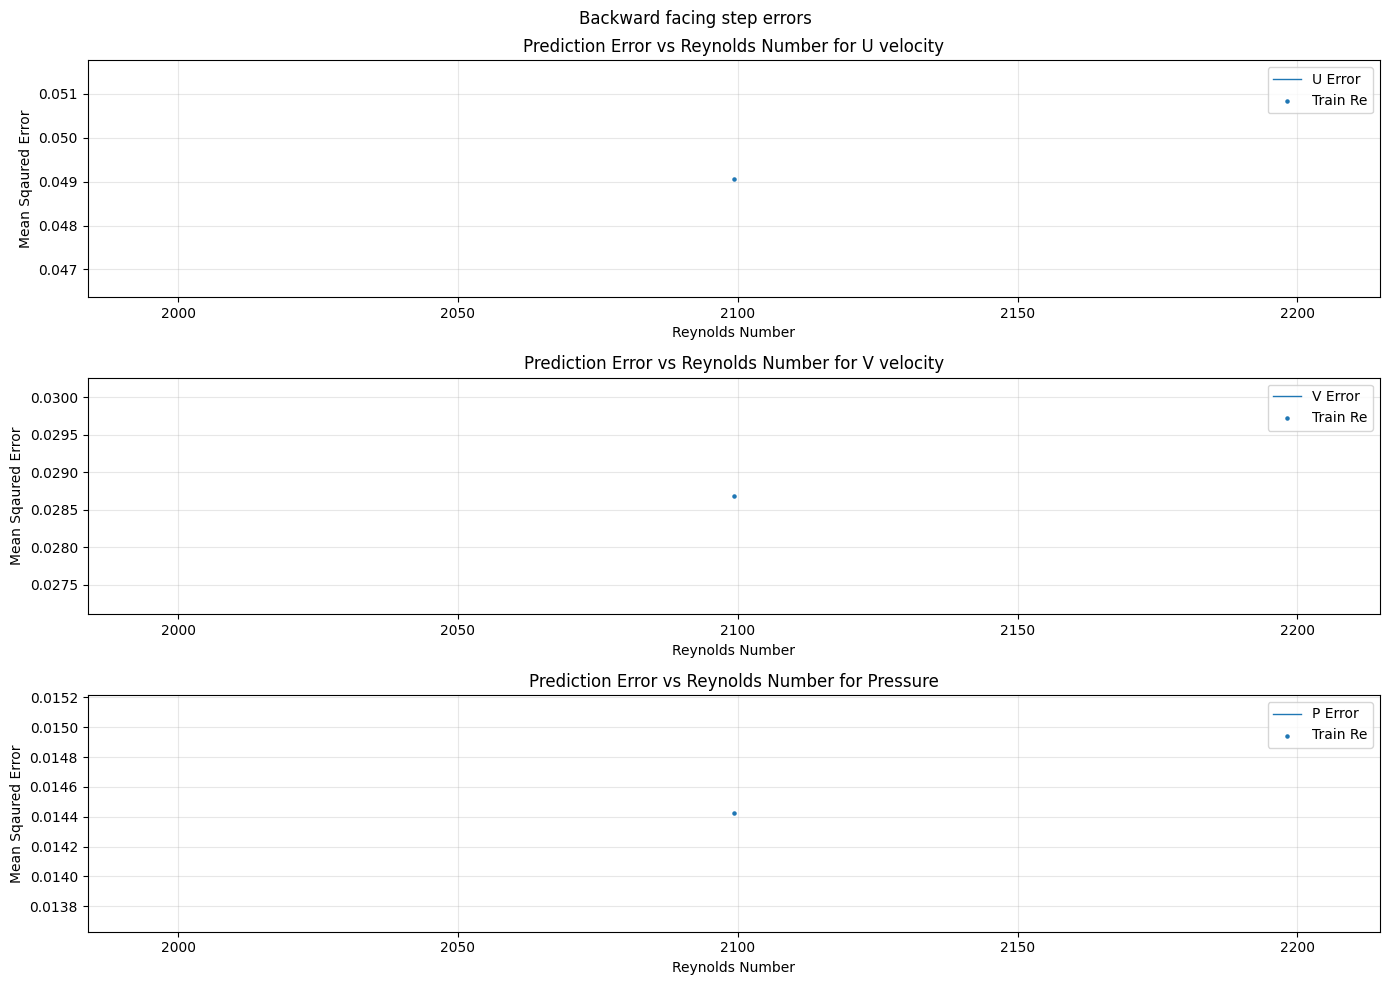

In [55]:
df = pd.DataFrame(errors).T.reset_index()
df = df.rename(columns={"index": "Re"})
df = df.sort_values("Re")

train_df = df

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Lines
axes[0].plot(df["Re"], df["u_error"], label="U Error", linewidth=1)


# Train points
axes[0].scatter(
    train_df["Re"],
    train_df["u_error"],
    marker="o",
    s=5,
    label="Train Re",
    # color = "yellow"
)


axes[0].set_xlabel("Reynolds Number")
axes[0].set_ylabel("Mean Sqaured Error")
axes[0].set_title("Prediction Error vs Reynolds Number for U velocity")
axes[0].legend()

axes[0].grid(alpha=0.3)


axes[1].plot(df["Re"], df["v_error"], label="V Error", linewidth=1)

# Train points
axes[1].scatter(
    train_df["Re"],
    train_df["v_error"],
    marker="o",
    s=5,
    label="Train Re",
    # color = "yellow"
)

axes[1].set_xlabel("Reynolds Number")
axes[1].set_ylabel("Mean Sqaured Error")
axes[1].set_title("Prediction Error vs Reynolds Number for V velocity")
axes[1].legend()

axes[1].grid(alpha=0.3)




axes[2].plot(df["Re"], df["p_error"], label="P Error", linewidth=1)

# Train points
axes[2].scatter(
    train_df["Re"],
    train_df["p_error"],
    marker="o",
    s=5,
    label="Train Re",
    # color = "yellow"
)

axes[2].set_xlabel("Reynolds Number")
axes[2].set_ylabel("Mean Sqaured Error")
axes[2].set_title("Prediction Error vs Reynolds Number for Pressure")
axes[2].legend()

axes[2].grid(alpha=0.3)

fig.suptitle("Backward facing step errors")
plt.tight_layout()
plt.show()